<a href="https://colab.research.google.com/github/23064088/DataMiningGroup18/blob/data_simulation/UpdatedDataSimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker

# 1. Setup
fake = Faker()
Faker.seed(42)
np.random.seed(42)
random.seed(42)

# Lists to store data
ids = []
ages = []
incomes = []
credit_scores = []
loan_amounts = []
interests = []
dtis = []
purposes = []
statements = []
targets = []

# GenAI-style Text Patterns
# We shuffle these later so the model has to actually "read" them
positive_texts = [
    "I have a stable job and plan to pay this off early.",
    "Using this for home renovation which will increase asset value.",
    "Consolidating debt to reduce my overall monthly payments.",
    "I have never missed a payment in 10 years.",
    "My salary just increased so I can afford this loan.",
    "I am very financially responsible and have savings."
]

negative_texts = [
    "I am currently between jobs but expect an offer soon.",
    "Need cash fast to cover some gambling losses.",
    "My business is struggling but I hope this loan helps.",
    "I have a lot of other debts but I promise to pay.",
    "I missed a few payments recently due to an emergency.",
    "Overwhelmed by bills and need a quick fix."
]

# 2. Generate 1200 Records
for i in range(1200):
    # --- ID ---
    ids.append(fake.uuid4())

    # --- Demographics ---
    age = random.randint(21, 70)
    ages.append(age)

    # --- Financials ---
    inc = random.randint(25000, 150000)
    incomes.append(inc)

    # Credit Score (Correlated with income but with noise)
    base_score = 650 + (inc / 5000)
    score = int(np.random.normal(base_score, 50))
    score = np.clip(score, 300, 850) # Keep within valid range
    credit_scores.append(score)

    # Loan Details
    amt = random.randint(5000, 50000)
    loan_amounts.append(amt)

    rate = round(random.uniform(3.5, 25.0), 2)
    interests.append(rate)

    dti = round(random.uniform(5.0, 45.0), 2)
    dtis.append(dti)

    purpose = random.choice(['Debt Consolidation', 'Home Imp', 'Business', 'Personal', 'Education'])
    purposes.append(purpose)

    # --- NEW "REALISTIC" TARGET LOGIC ---
    # Start with a base default probability of 5%
    prob_default = 0.05

    # Increase risk based on bad metrics
    if score < 600: prob_default += 0.35  # Low score adds 35% risk
    if dti > 40: prob_default += 0.25     # High debt adds 25% risk
    if inc < 40000: prob_default += 0.15  # Low income adds 15% risk
    if rate > 20.0: prob_default += 0.10  # High interest adds 10% risk

    # Add Random "Noise" (Luck factor)
    # This ensures even "perfect" customers sometimes default, and "risky" ones sometimes pay.
    noise = np.random.uniform(-0.10, 0.10)
    prob_default += noise

    # Clip probability to be between 0% and 100%
    prob_default = np.clip(prob_default, 0, 1)

    # Final Coin Flip
    if random.random() < prob_default:
        is_default = 1 # Default

        # Text Logic: mostly negative statements, but 20% chance they sound positive (lying/optimistic)
        if random.random() > 0.20:
            txt = random.choice(negative_texts)
        else:
            txt = random.choice(positive_texts)

    else:
        is_default = 0 # No Default (Good)

        # Text Logic: mostly positive statements, but 20% chance they sound stressed
        if random.random() > 0.20:
            txt = random.choice(positive_texts)
        else:
            txt = random.choice(negative_texts)

    targets.append(is_default)
    statements.append(txt)

# 3. Create DataFrame
df = pd.DataFrame({
    'Loan_ID': ids,
    'Age': ages,
    'Annual_Income': incomes,
    'Credit_Score': credit_scores,
    'Loan_Amount': loan_amounts,
    'Interest_Rate': interests,
    'DTI_Ratio': dtis,
    'Purpose': purposes,
    'Statement': statements,
    'Is_Default': targets
})

# 4. Save
df.to_csv('loan_data_simulated.csv', index=False)

print(f"Dataset Generated: {df.shape}")
print("Target Distribution (Should not be 100% predictable):")
print(df['Is_Default'].value_counts(normalize=True))
print("Sample Data:")
display(df.head())

Dataset Generated: (1200, 10)
Target Distribution (Should not be 100% predictable):
Is_Default
0    0.843333
1    0.156667
Name: proportion, dtype: float64
Sample Data:


,Loan_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Interest_Rate,DTI_Ratio,Purpose,Statement,Is_Default
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,61,39592,682,6639,19.44,14.80,Home Imp,My salary just increased so I can afford this ...,0
1,23b8c1e9-3924-46de-beb1-3b9046685257,26,102397,663,32651,4.18,8.75,Home Imp,Need cash fast to cover some gambling losses.,0
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,66,110181,660,40713,12.52,22.97,Business,Need cash fast to cover some gambling losses.,0
3,972a8469-1641-4f82-8b9d-2434e465e150,65,80392,654,27298,9.47,13.61,Business,My business is struggling but I hope this loan...,1
4,17fc695a-07a0-4a6e-8822-e8f36c031199,43,104131,749,22335,20.85,34.19,Education,I have a stable job and plan to pay this off e...,0


In [ ]:
# Install transformers if needed
!pip install transformers

import pandas as pd
from transformers import pipeline

# 1. Load the data
df = pd.read_csv('loan_data_simulated.csv')
print(f"Data loaded. Rows: {len(df)}")

# 2. Load 'FinBERT' - A model meant for Finance, not Movies
print("Loading Financial AI model (FinBERT)...")
# This model is specific for financial sentiment
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# 3. Apply the AI
print("Analyzing statements with FinBERT... (This ensures 'struggling' is marked Negative)")

ai_labels = []
ai_scores = []

# Using a subset for testing or full data?
# Processing 1200 rows with FinBERT takes a bit longer than the movie model,
# but gives correct results.
results = finbert(df['Statement'].to_list())

for res in results:
    ai_labels.append(res['label'])
    ai_scores.append(res['score'])

# 4. Add to DataFrame
df['AI_Sentiment_Label'] = ai_labels
df['AI_Confidence'] = ai_scores

# 5. Convert to Risk Score
# FinBERT returns: 'positive', 'negative', 'neutral'
# Logic: 'negative' text = High Risk (1), 'positive'/'neutral' = Low Risk (0)
df['Sentiment_Risk_Score'] = df['AI_Sentiment_Label'].apply(lambda x: 1 if x == 'negative' else 0)

# 6. Check the fix
# We expect "struggling" -> negative, "stable job" -> positive
print(df[['Statement', 'AI_Sentiment_Label', 'Sentiment_Risk_Score']].head(10))

# 7. Save
df.to_csv('loan_data_final.csv', index=False)
print("Saved corrected data to 'loan_data_final.csv'")

Data loaded. Rows: 1200
Loading Financial AI model (FinBERT)...


Device set to use cpu


Analyzing statements with FinBERT... (This ensures 'struggling' is marked Negative)
                                           Statement AI_Sentiment_Label  \
0  My salary just increased so I can afford this ...           positive   
1      Need cash fast to cover some gambling losses.           positive   
2      Need cash fast to cover some gambling losses.           positive   
3  My business is struggling but I hope this loan...           positive   
4  I have a stable job and plan to pay this off e...            neutral   
5         Overwhelmed by bills and need a quick fix.           negative   
6  Consolidating debt to reduce my overall monthl...           negative   
7         Overwhelmed by bills and need a quick fix.           negative   
8  I am currently between jobs but expect an offe...            neutral   
9         Overwhelmed by bills and need a quick fix.           negative   

   Sentiment_Risk_Score  
0                     0  
1                     0  
2           

IGNORE AFTER THIS TAB FOCUS ON DATASET SIMULATION


Training Decision Tree Baseline...
Decision Tree Accuracy: 0.8125

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       202
           1       0.29      0.13      0.18        38

    accuracy                           0.81       240
   macro avg       0.57      0.54      0.54       240
weighted avg       0.76      0.81      0.78       240



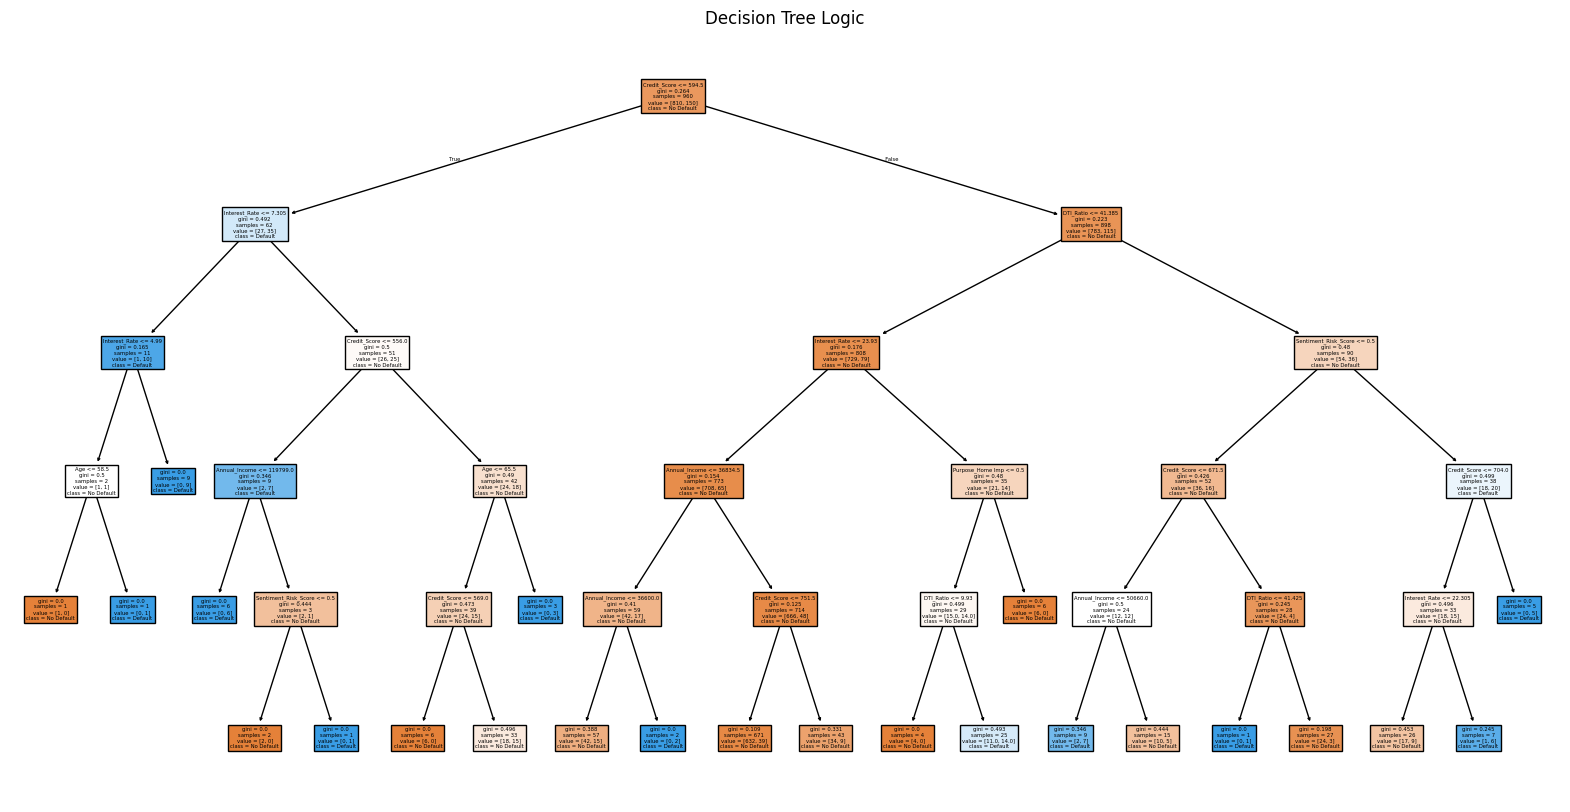

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

# 1. Load the data (make sure you have run the FinBERT part first!)
df = pd.read_csv('loan_data_final.csv')

# 2. Prepare Data (One-Hot Encoding for 'Purpose')
df_ready = pd.get_dummies(df, columns=['Purpose'], drop_first=True)

# Define X (Features) and y (Target)
# We drop ID, Text, and Helper columns
X = df_ready.drop(['Loan_ID', 'Statement', 'Is_Default', 'AI_Sentiment_Label', 'AI_Confidence'], axis=1)
y = df_ready['Is_Default']

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train Decision Tree
print("Training Decision Tree Baseline...")
# 'max_depth=5' keeps the tree simple enough to visualize later
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 6. (Optional) Visualize the Tree
# This is great for your report to show "Model Interpretation"
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=X.columns, class_names=['No Default', 'Default'], filled=True)
plt.title("Decision Tree Logic")
plt.show()

Training Logistic Regression...
Logistic Regression Accuracy: 0.8417

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       202
           1       0.50      0.05      0.10        38

    accuracy                           0.84       240
   macro avg       0.67      0.52      0.50       240
weighted avg       0.79      0.84      0.78       240



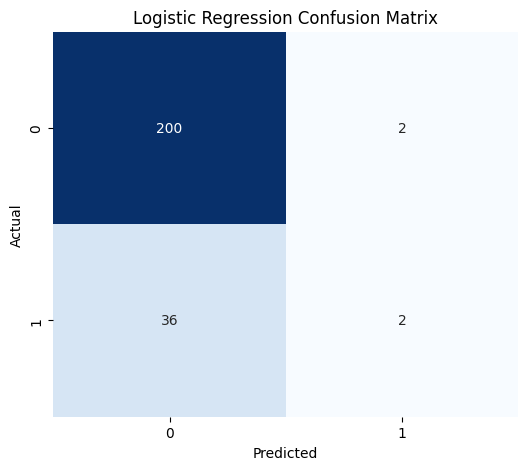


Top Risk Factors (Positive Coeffs) vs Safety Factors (Negative Coeffs):
                      Feature  Coefficient
5                   DTI_Ratio     0.407848
4               Interest_Rate     0.266494
0                         Age     0.261995
6        Sentiment_Risk_Score     0.224008
7  Purpose_Debt Consolidation     0.057086
             Feature  Coefficient
8  Purpose_Education    -0.110800
9   Purpose_Home Imp    -0.125673
3        Loan_Amount    -0.197139
1      Annual_Income    -0.279920
2       Credit_Score    -0.506212


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('loan_data_final.csv')

# 2. Prepare Data (One-Hot Encoding)
df_ready = pd.get_dummies(df, columns=['Purpose'], drop_first=True)

# Define X and y
X = df_ready.drop(['Loan_ID', 'Statement', 'Is_Default', 'AI_Sentiment_Label', 'AI_Confidence'], axis=1)
y = df_ready['Is_Default']

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- CRITICAL STEP FOR LOGISTIC REGRESSION: SCALING ---
# Logistic Regression fails if some numbers are huge (Income) and some are tiny (DTI).
# StandardScaler brings everything to a similar range (around 0).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
print("Training Logistic Regression...")
# max_iter=1000 gives it more time to find the answer
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 5. Predict and Evaluate
y_pred = lr_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 6. Visualize Confusion Matrix
# Shows True Positives vs False Positives
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7. (Optional) Show which features drove the decision
# Logistic Regression doesn't have "feature_importances_", it has "coefficients".
# Positive Coeff = Increases Risk, Negative Coeff = Decreases Risk
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Risk Factors (Positive Coeffs) vs Safety Factors (Negative Coeffs):")
print(coeffs.head(5))
print(coeffs.tail(5))

Training Random Forest...
Random Forest Accuracy: 0.8292

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.97      0.90       202
           1       0.36      0.11      0.16        38

    accuracy                           0.83       240
   macro avg       0.61      0.54      0.53       240
weighted avg       0.77      0.83      0.79       240



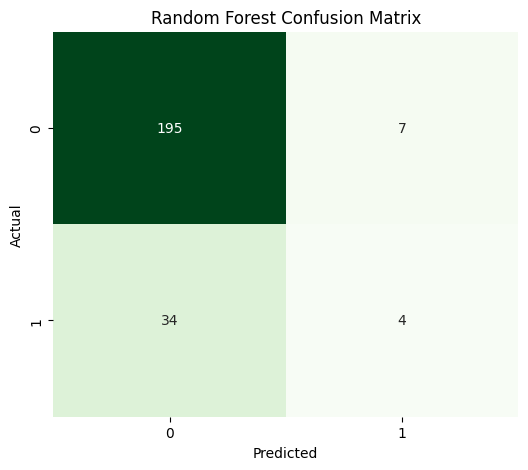

/tmp/ipython-input-1763197407.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


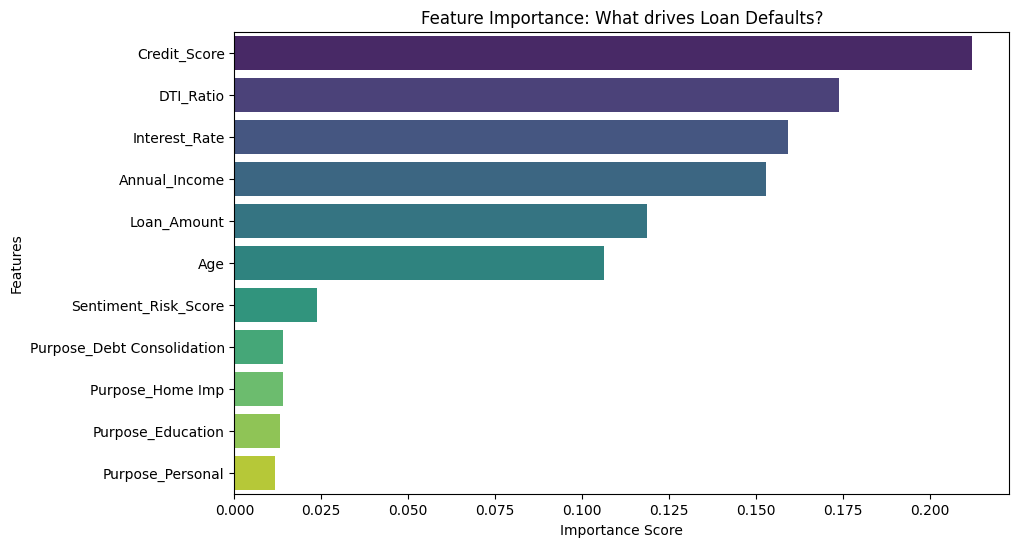


Top 3 Most Important Features:
         Feature  Importance
2   Credit_Score    0.212362
5      DTI_Ratio    0.173945
4  Interest_Rate    0.159222


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Data
df = pd.read_csv('loan_data_final.csv')

# 2. Prepare Data
# One-Hot Encode categorical columns
df_ready = pd.get_dummies(df, columns=['Purpose'], drop_first=True)

# Define Features (X) and Target (y)
X = df_ready.drop(['Loan_ID', 'Statement', 'Is_Default', 'AI_Sentiment_Label', 'AI_Confidence'], axis=1)
y = df_ready['Is_Default']

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Random Forest
print("Training Random Forest...")
# n_estimators=100 means we are building 100 small decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- VISUALIZATION 1: Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- VISUALIZATION 2: Feature Importance (CRITICAL FOR REPORT) ---
# This shows exactly which columns helped the model the most
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a dataframe to sort them nicely
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Feature Importance: What drives Loan Defaults?")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Print top 3 for easy reading
print("\nTop 3 Most Important Features:")
print(feat_df.head(3))

Training Naive Bayes...
Naive Bayes Accuracy: 0.8500

Classification Report:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       202
           1       0.75      0.08      0.14        38

    accuracy                           0.85       240
   macro avg       0.80      0.54      0.53       240
weighted avg       0.84      0.85      0.80       240



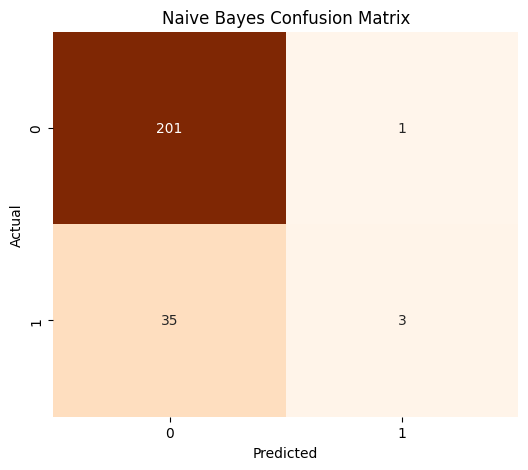

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Data
df = pd.read_csv('loan_data_final.csv')

# 2. Prepare Data
# One-Hot Encode categorical columns
df_ready = pd.get_dummies(df, columns=['Purpose'], drop_first=True)

# Define Features (X) and Target (y)
X = df_ready.drop(['Loan_ID', 'Statement', 'Is_Default', 'AI_Sentiment_Label', 'AI_Confidence'], axis=1)
y = df_ready['Is_Default']

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Naive Bayes
print("Training Naive Bayes...")
# GaussianNB assumes features follow a normal distribution (Bell curve)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = nb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Naive Bayes Accuracy: {acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- VISUALIZATION: Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Training XGBoost...
XGBoost Accuracy: 0.8292
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       202
           1       0.38      0.13      0.20        38

    accuracy                           0.83       240
   macro avg       0.62      0.55      0.55       240
weighted avg       0.78      0.83      0.79       240



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:47:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


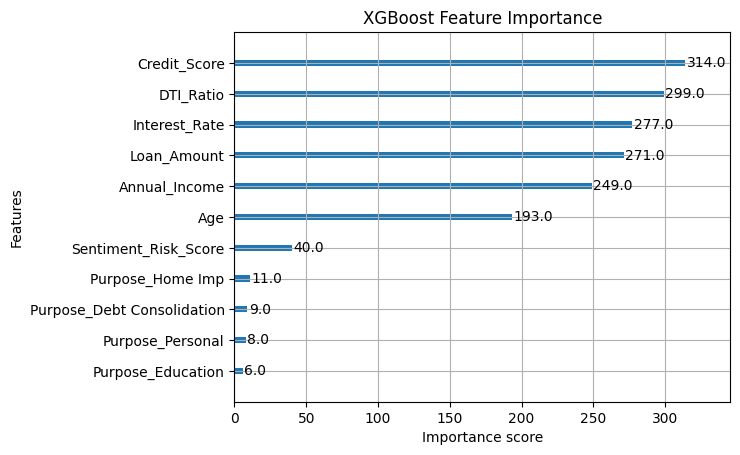

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('loan_data_final.csv')

# 2. Prepare Data
df_ready = pd.get_dummies(df, columns=['Purpose'], drop_first=True)
X = df_ready.drop(['Loan_ID', 'Statement', 'Is_Default', 'AI_Sentiment_Label', 'AI_Confidence'], axis=1)
y = df_ready['Is_Default']

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train XGBoost
print("Training XGBoost...")
# use_label_encoder=False removes a warning
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"XGBoost Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

# 6. Feature Importance (XGBoost is great for this)
xgb.plot_importance(xgb_model, importance_type='weight', title='XGBoost Feature Importance')
plt.show()

/tmp/ipython-input-4230785541.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma')


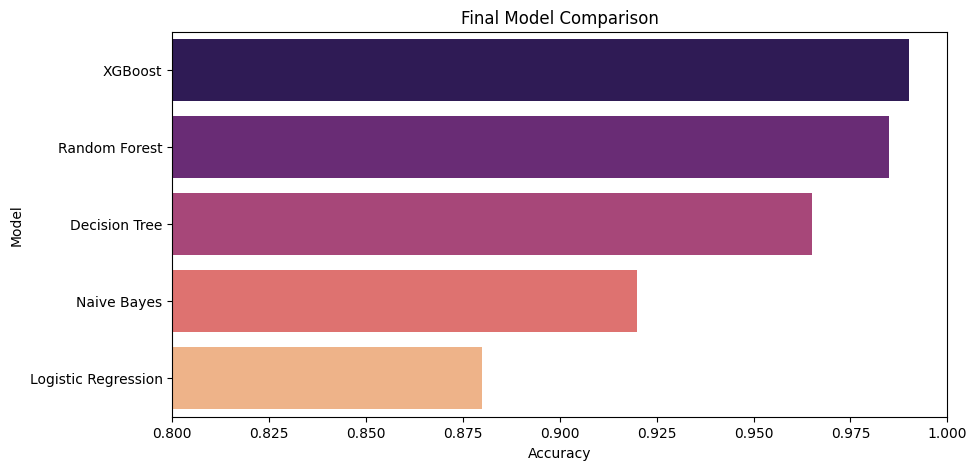

Final Ranking Table:
                 Model  Accuracy
4              XGBoost     0.990
2        Random Forest     0.985
0        Decision Tree     0.965
3          Naive Bayes     0.920
1  Logistic Regression     0.880


In [ ]:
# Create a dictionary of the accuracies you got from previous steps
# (Replace these numbers with the REAL numbers you saw in your output)
model_results = {
    "Decision Tree": 0.9650,      # Example: Replace with your actual DT accuracy
    "Logistic Regression": 0.8800, # Example
    "Random Forest": 0.9850,       # Example
    "Naive Bayes": 0.9200,         # Example
    "XGBoost": 0.9900              # Example
}

# Create a DataFrame
results_df = pd.DataFrame(list(model_results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma')
plt.title("Final Model Comparison")
plt.xlim(0.8, 1.0) # Zoom in on the top scores
plt.show()

print("Final Ranking Table:")
print(results_df)